# SPRINT 11: Visualització de Dades amb Python i Power BI

## NIVELL 1

Connecta Python amb MySQL Workbench i carrega les dades de la teva base de dades del Sprint 4 per utilitzar-les en tots els exercicis.

1. Connecta Python amb MySQL Workbench i carrega les dades de la teva base de dades del Sprint 4 per utilitzar-les en tots els exercicis.

In [247]:
pip install mysql-connector-python

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [248]:
import mysql.connector
import pandas as pd

In [249]:
# conexió al database
conexio = mysql.connector.connect(
        host = 'localhost',
        user = 'root',
        password = 'Alamedas.789',
        port = 3306,
        database = 'sprint_4'
    )  

# obtenir el nom de les taules
taules = pd.read_sql('SHOW TABLES', conexio)

# diccionario per a guardar els dataframes
dfs = {}

# carrego les taules del database de SQL i li asigno els valors al diccionari
# taules.iloc[:,0] pren el nom de les taules
for taula_nom in taules.iloc[:,0]:
    # carrega la taula en un dataframe
    df = pd.read_sql(f"SELECT * FROM {taula_nom}\n", conexio)
    # guarda la taula en els valors y taula_nom en les claus
    dfs[taula_nom]=df
    print(f" - {taula_nom} carregada: {len(df)} rows")

conexio.close()
print("\n conexion cerrada.")

companies = dfs['companies']
credit_cards = dfs['credit_cards']
card_status = dfs['estat_targetes']
products = dfs['products']
transactions = dfs['transactions']
transactions_products = dfs['transactions_products']
users = dfs['users']

C:\Users\marco\AppData\Local\Temp\ipykernel_27156\3849810829.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  taules = pd.read_sql('SHOW TABLES', conexio)
C:\Users\marco\AppData\Local\Temp\ipykernel_27156\3849810829.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(f"SELECT * FROM {taula_nom}\n", conexio)


 - companies carregada: 100 rows
 - credit_cards carregada: 5000 rows
 - estat_targetes carregada: 5000 rows
 - products carregada: 100 rows
 - transactions carregada: 100000 rows
 - transactions_products carregada: 253391 rows
 - users carregada: 5000 rows

 conexion cerrada.


2. Per a cada ítem, crea una visualització adequada segons les variables especificades. Interpreta els resultats segons les teves dades.

Recorda: quan seleccionis les columnes, pensa sempre en el mètode que faràs servir i inclou les que calguin per a la funció de visualització que vulguis utilitzar.

In [250]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import nbformat

- Una variable numérica

Pandas: Histograma del preu dels productes

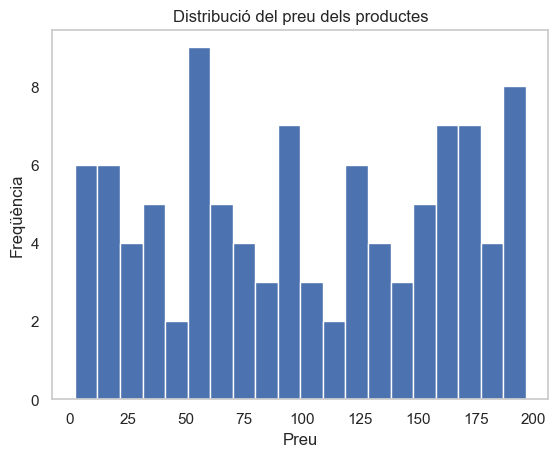

In [251]:
products['price'].plot.hist(bins = 20)
plt.xlabel('Preu')
plt.ylabel('Freqüència')
plt.title('Distribució del preu dels productes')
plt.show();

Pandas: Kde del preu dels productes

In [252]:
pip install scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


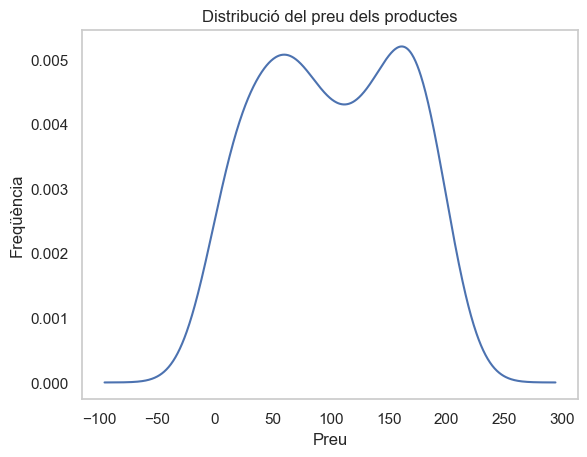

In [253]:
products['price'].plot.kde()
plt.xlabel('Preu')
plt.ylabel('Freqüència')
plt.title('Distribució del preu dels productes')
plt.show();

Pandas: Boxplot del preu dels productes

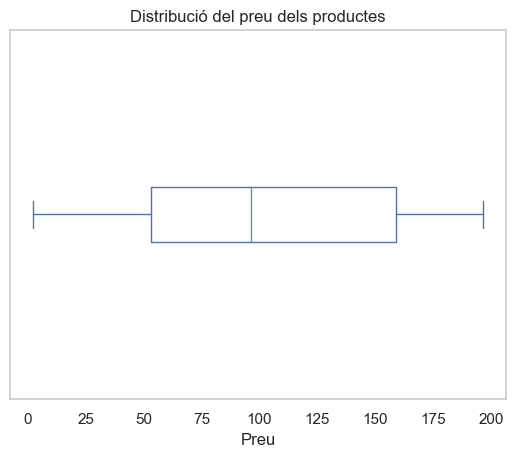

In [254]:
products['price'].plot.box(vert=False)

plt.xlabel('Preu')
plt.yticks([])

plt.title('Distribució del preu dels productes')
plt.show()

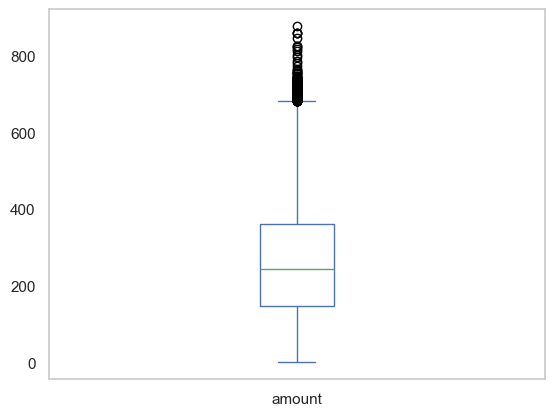

In [255]:
transactions['amount'].plot.box();

Matplotlib: Histograma del preu dels productes

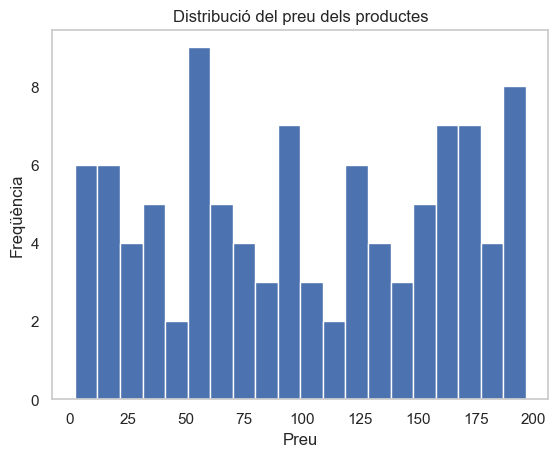

In [256]:
plt.hist(products['price'], bins = 20)
plt.xlabel('Preu')
plt.ylabel('Freqüència')
plt.title('Distribució del preu dels productes')
plt.show()

Matplotlib: Boxplot i Violinplot del preu dels productes

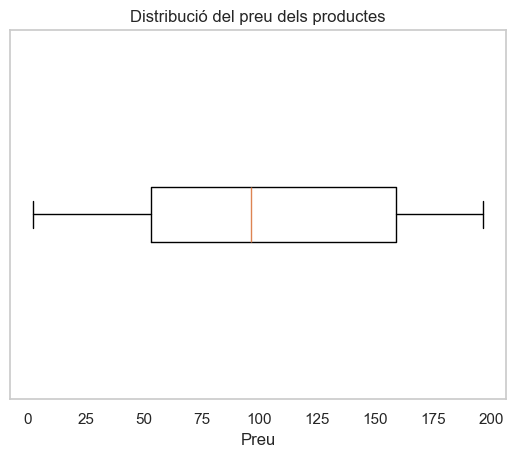

In [257]:
plt.boxplot(products['price'], vert=False)
plt.xlabel('Preu')
plt.yticks([])
plt.title('Distribució del preu dels productes')
plt.show()

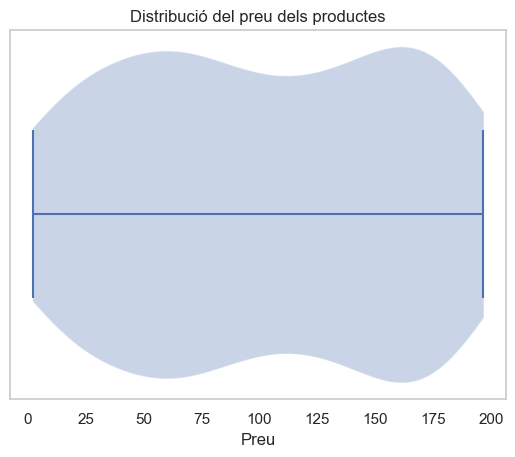

In [258]:
plt.violinplot(products['price'], vert=False)
plt.xlabel('Preu')
plt.yticks([])
plt.title('Distribució del preu dels productes')
plt.show()

Seaborn: Histograma + kde del preu dels productes

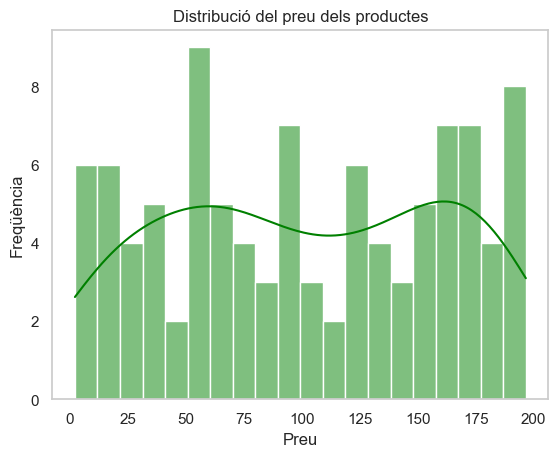

In [259]:
sns.histplot(data = products, x= 'price', bins = 20, color = 'green', kde=True)
plt.xlabel('Preu')
plt.ylabel('Freqüència')
plt.title('Distribució del preu dels productes')
plt.show()


Seaborn: Boxplot i Violinplot del preu dels productes

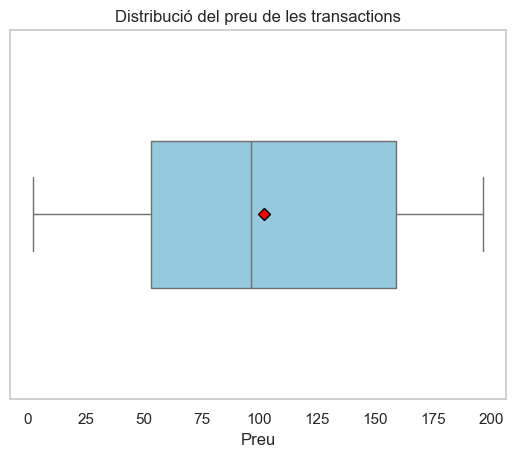

In [260]:
sns.boxplot(data = products, x= 'price', color='skyblue', width=0.4, showmeans=True, meanprops={  # La media
        'marker': 'D',
        'markerfacecolor': 'red',
        'markeredgecolor': 'black'
    },
    flierprops={                                        # Outliers
        'marker': 'o',
        'markersize': 4,
        'markerfacecolor': 'orange'
    })
plt.xlabel('Preu')
plt.ylabel('')
plt.title('Distribució del preu de les transactions')
plt.show()

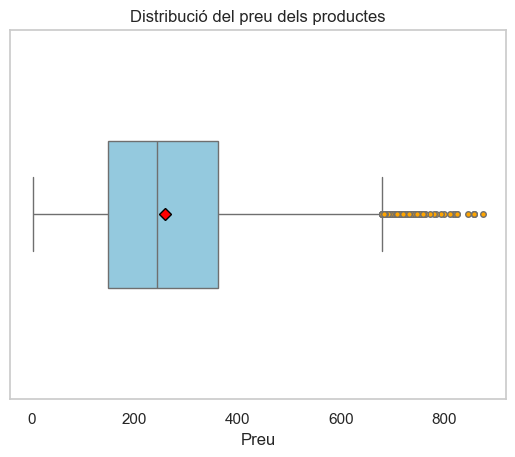

In [261]:
sns.boxplot(data = transactions, x= 'amount', color='skyblue', width=0.4, showmeans=True, meanprops={  # La media
        'marker': 'D',
        'markerfacecolor': 'red',
        'markeredgecolor': 'black'
    },
    flierprops={                                        # Outliers
        'marker': 'o',
        'markersize': 4,
        'markerfacecolor': 'orange'
    })
plt.xlabel('Preu')
plt.ylabel('')
plt.title('Distribució del preu dels productes')
plt.show()

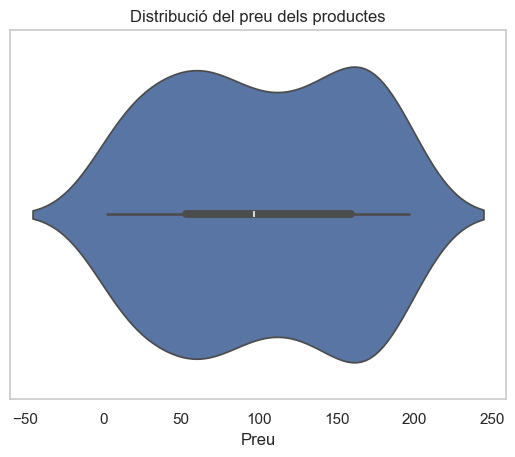

In [262]:
sns.violinplot(data = products, x= 'price')
plt.xlabel('Preu')
plt.ylabel('')
plt.title('Distribució del preu dels productes')
plt.show()

- Dues variables numèriques

Pandas: Scatterplot

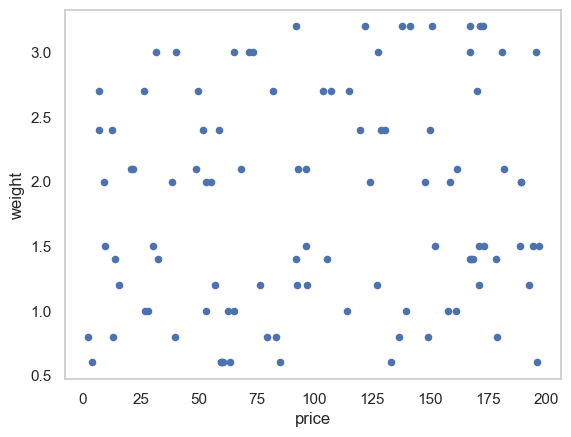

In [263]:
products['weight'] = pd.to_numeric(products['weight'])
products.plot.scatter(x='price', y='weight');

Matplotlib: Scatterplot

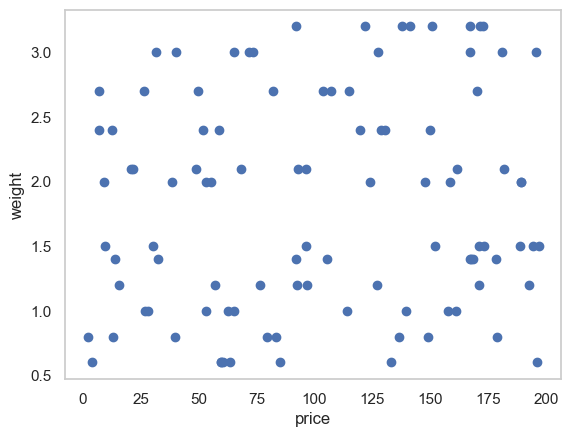

In [264]:
plt.scatter(products['price'], products['weight'])
plt.xlabel('price')
plt.ylabel('weight')
plt.show()

Seaborn: Scatterplot

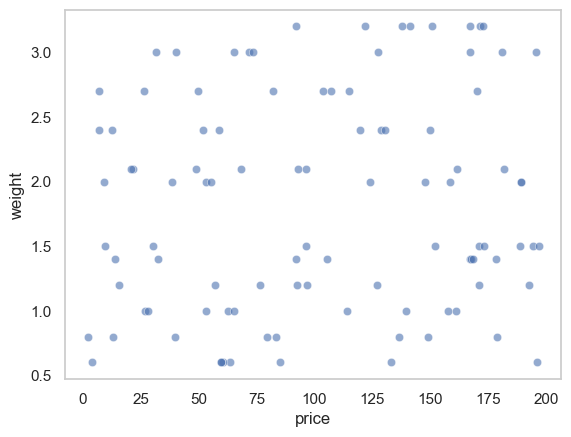

In [265]:
sns.scatterplot(data=products, x='price', y='weight', alpha=0.6)

plt.show()

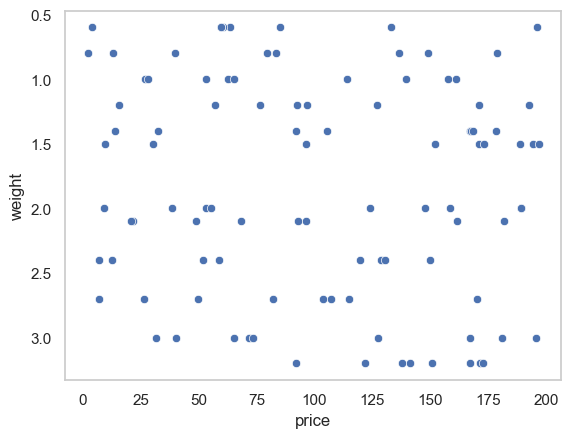

In [266]:
ax = sns.scatterplot(data=products, x='price', y='weight')  # Con el eje Y invertido

ax.invert_yaxis()

plt.show()

,price,weight
price,1.000000,0.105431
weight,0.105431,1.000000


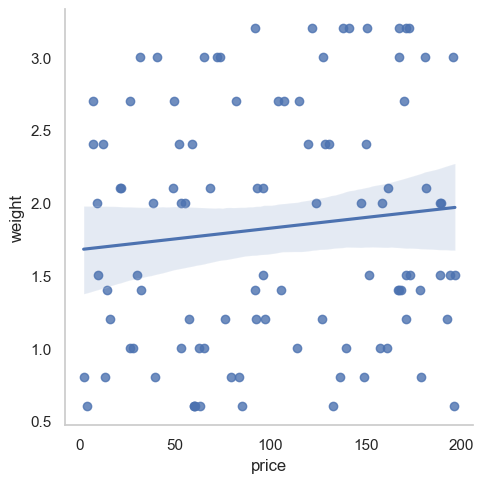

In [285]:
products['weight'] = pd.to_numeric(products['weight'], errors="coerce")
sns.lmplot(data=products, x='price', y='weight')
products[["price", "weight"]].corr()

Existe una asociación lineal positiva muy débil entre el precio y el peso de los productos; la correlación lineal parece cercana a cero.
Aunque el modelo lineal muestra una ligera tendencia creciente, la dispersión de los datos es alta y la correlación (r ≈ 0.10) indica que el precio explica muy poco la variabilidad del peso. En la práctica, el precio no es un buen predictor del peso

- Una variable categòrica

Pandas: Barres amb la quantitat de companyies per països

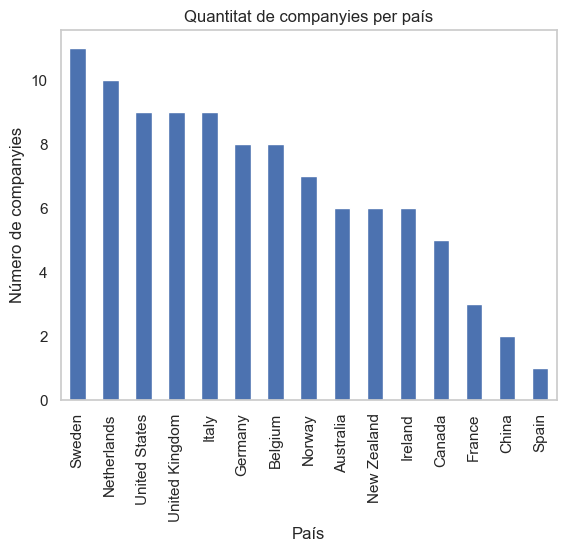

In [193]:
companies['country'].value_counts().plot.bar();
plt.xlabel('País')
plt.ylabel('Número de companyies')
plt.title('Quantitat de companyies per país');

Pandas: Treemap amb quantitat de companyies per països

In [171]:
!pip install squarify
import squarify


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


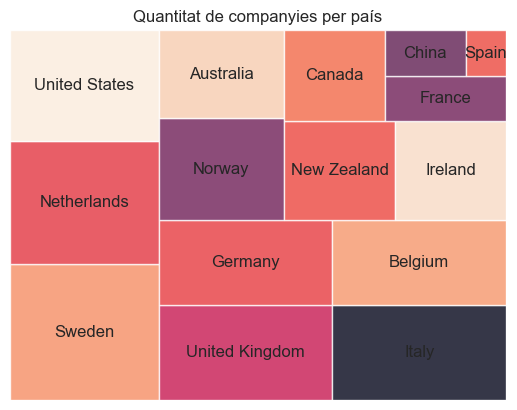

In [194]:
country_counts = companies['country'].value_counts().sort_values(ascending=False)

squarify.plot(sizes=country_counts.values,
    label=country_counts.index,
    alpha=0.8)

plt.axis('off')
plt.title('Quantitat de companyies per país');

# No es posible ordenar el treemap de mayor a menor. Para ello, mejor las barras

Pandas: Diagrama sectors amb l'estat de les targetes

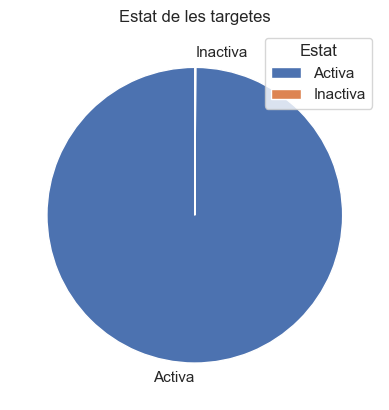

In [195]:
card_status['estat'].value_counts().plot.pie(startangle = 90)
plt.title('Estat de les targetes')
plt.ylabel('') #para eliminar el título automático del eje Y
plt.legend(title='Estat',loc='best')
plt.show()

Matplotlib: Barres amb la quantitat de companyies per països

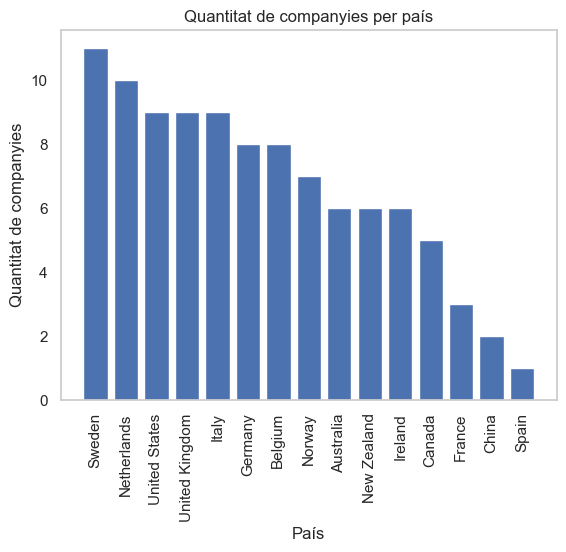

In [196]:
country_counts = companies['country'].value_counts()

plt.bar(
    x=country_counts.index,
    height=country_counts.values
)
plt.xlabel('País')
plt.ylabel('Quantitat de companyies')
plt.title('Quantitat de companyies per país')

plt.xticks(rotation=90) # Per a rotar els noms i que no es superponguin
plt.show()

Matplotlib: Treemap amb quantitat de companyies per països

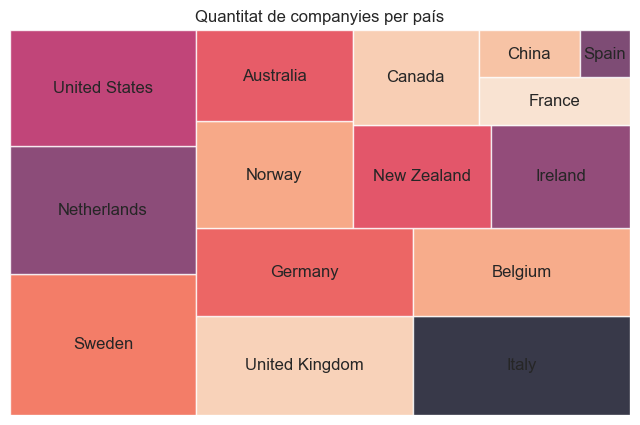

In [197]:
country_counts = companies['country'].value_counts()

plt.figure(figsize=(8, 5))

squarify.plot(sizes=country_counts.values,
    label=country_counts.index,
    alpha=0.8)

plt.axis('off')
plt.title('Quantitat de companyies per país');

plt.axis('off')
plt.show()

Matplotlib: Diagrama sectors amb l'estat de les targetes

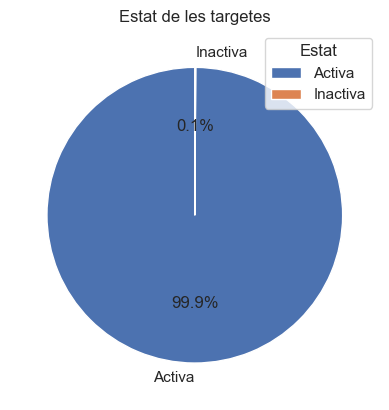

In [198]:
status_counts = card_status['estat'].value_counts()

plt.pie(
    status_counts,
    labels=status_counts.index,
    startangle=90,
    autopct='%1.1f%%' #para añadir el porcentaje
)

plt.title('Estat de les targetes')
plt.legend(title='Estat',loc='best')
plt.show()

Seaborn: Barres amb la quantitat de companyies per països

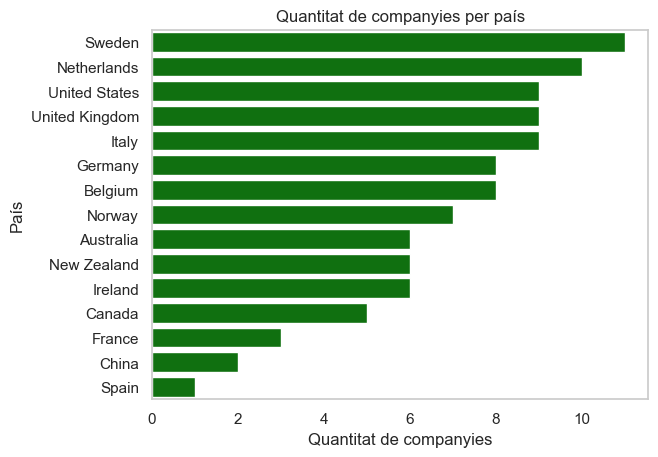

In [279]:
sns.countplot(data=companies, y='country', color='green', order=companies['country'].value_counts().index, width=0.8)

plt.xlabel('Quantitat de companyies')
plt.ylabel('País')
plt.title('Quantitat de companyies per país')

plt.show()

Pandas: Treemap amb quantitat de companyies per països

- Dues variables categòriques

Pandas: Barres apilades/agrupades

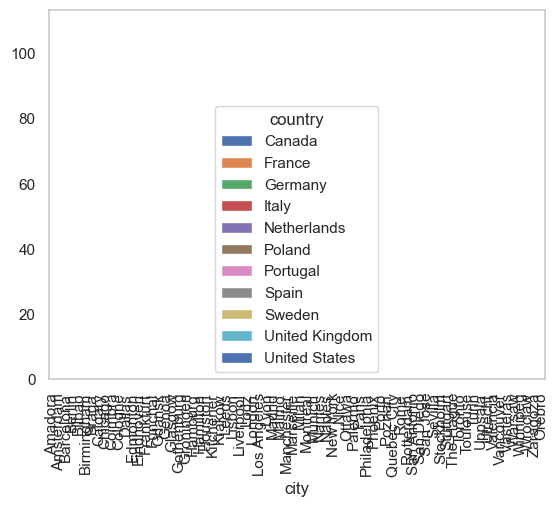

In [209]:
pd.crosstab(users['city'], users['country']).plot.bar();   # También se puede hacer con un groupby

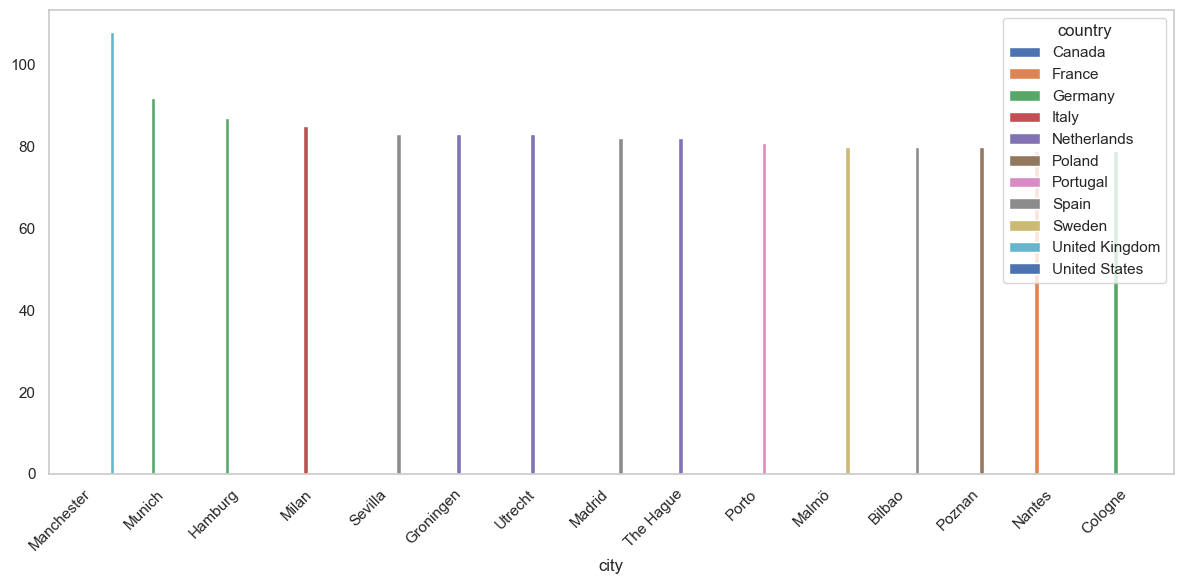

In [ ]:
tabla = pd.crosstab(users['city'], users['country'])

tabla = tabla.loc[tabla.sum(axis=1).sort_values(ascending=False).head(15).index]

ax = tabla.plot.bar(figsize=(12, 6), width=0.7)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

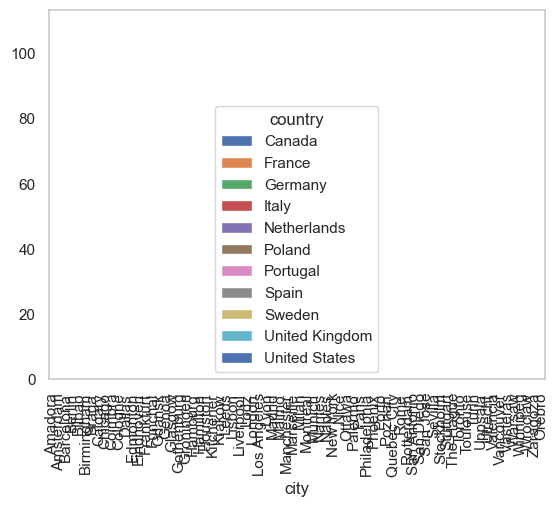

In [206]:
users.groupby(['city', 'country']).size().unstack().plot.bar();  # Con groupby en lugar de crosstab

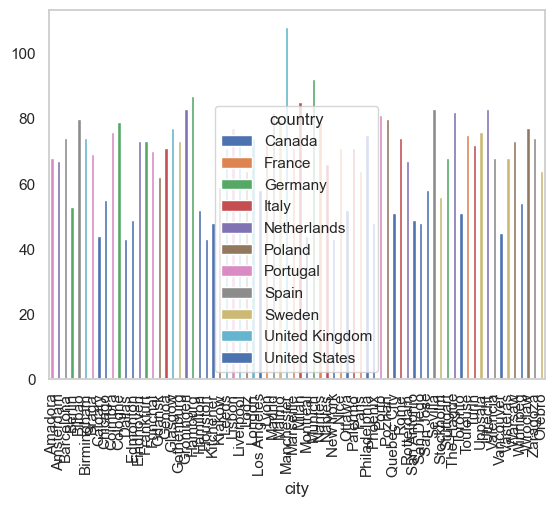

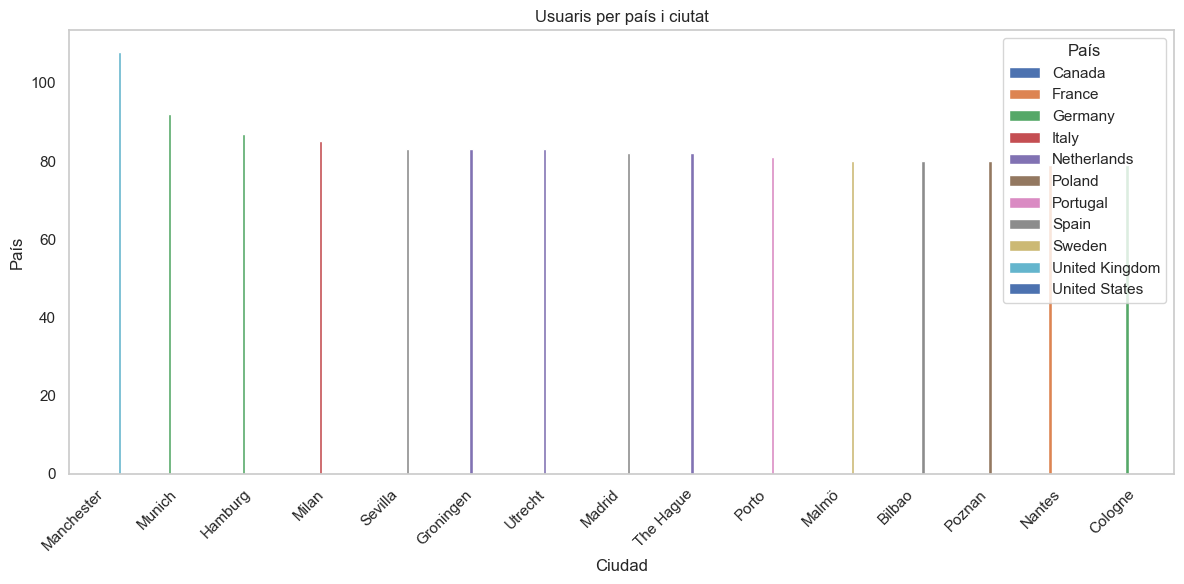

In [211]:
pd.crosstab(users['city'], users['country']).plot.bar(stacked=True); 

fig, ax = plt.subplots(figsize=(12, 6))
tabla.plot(kind='bar', ax=ax)

plt.xlabel('Ciudad')
plt.ylabel('País')
plt.title('Usuaris per país i ciutat')
plt.legend(title='País')
plt.xticks(rotation=45, ha='right')
plt.tight_layout() # Barras apiladas

Pandas: Heatmap

In [214]:
# No se puede

Matplotlib: Barres apilades/agrupades

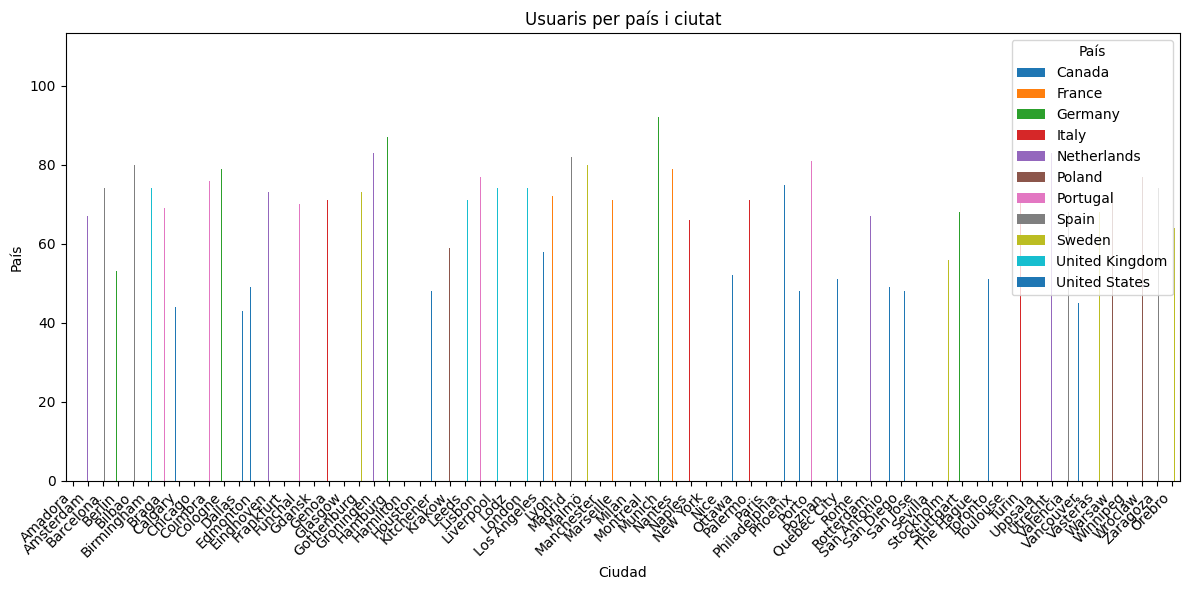

In [134]:
tabla = pd.crosstab(users['city'], users['country'])


fig, ax = plt.subplots(figsize=(12, 6))
tabla.plot(kind='bar', ax=ax)

plt.xlabel('Ciudad')
plt.ylabel('País')
plt.title('Usuaris per país i ciutat')
plt.legend(title='País')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Matplotlib: Heatmap

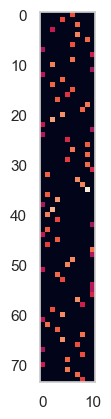

In [ ]:
tabla = pd.crosstab(users['city'], users['country']) # Muy básica y manual

plt.imshow(tabla)
plt.show()

Seaborn: Barres apilades/agrupades

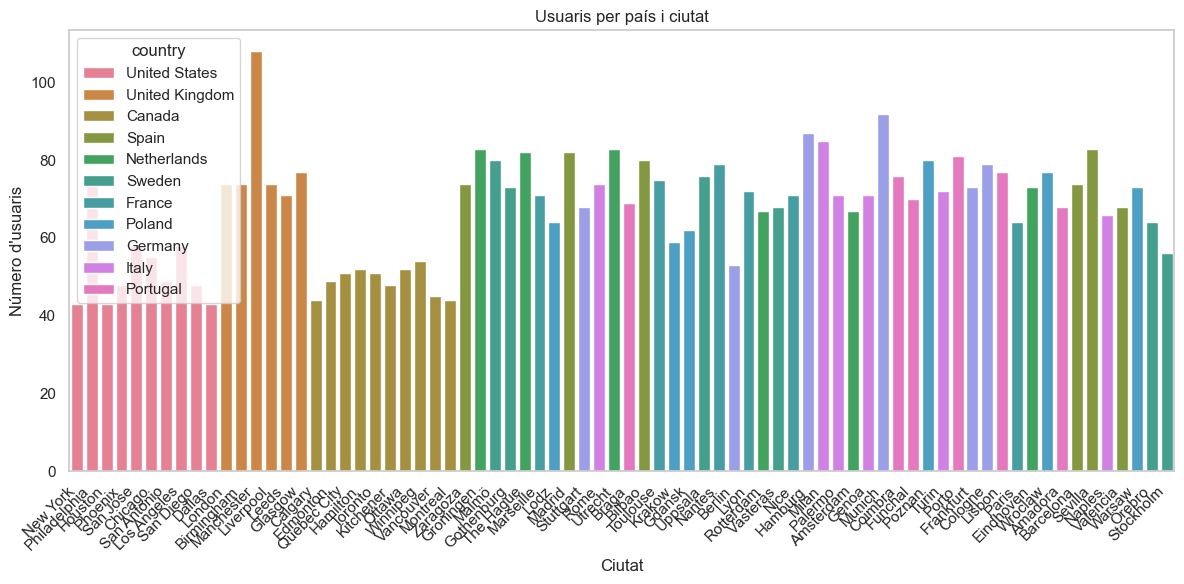

In [212]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=users,
    x='city',
    hue='country'
)

plt.xlabel('Ciutat')
plt.ylabel("Número d'usuaris")
plt.title('Usuaris per país i ciutat')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

Seaborn: Heatmap

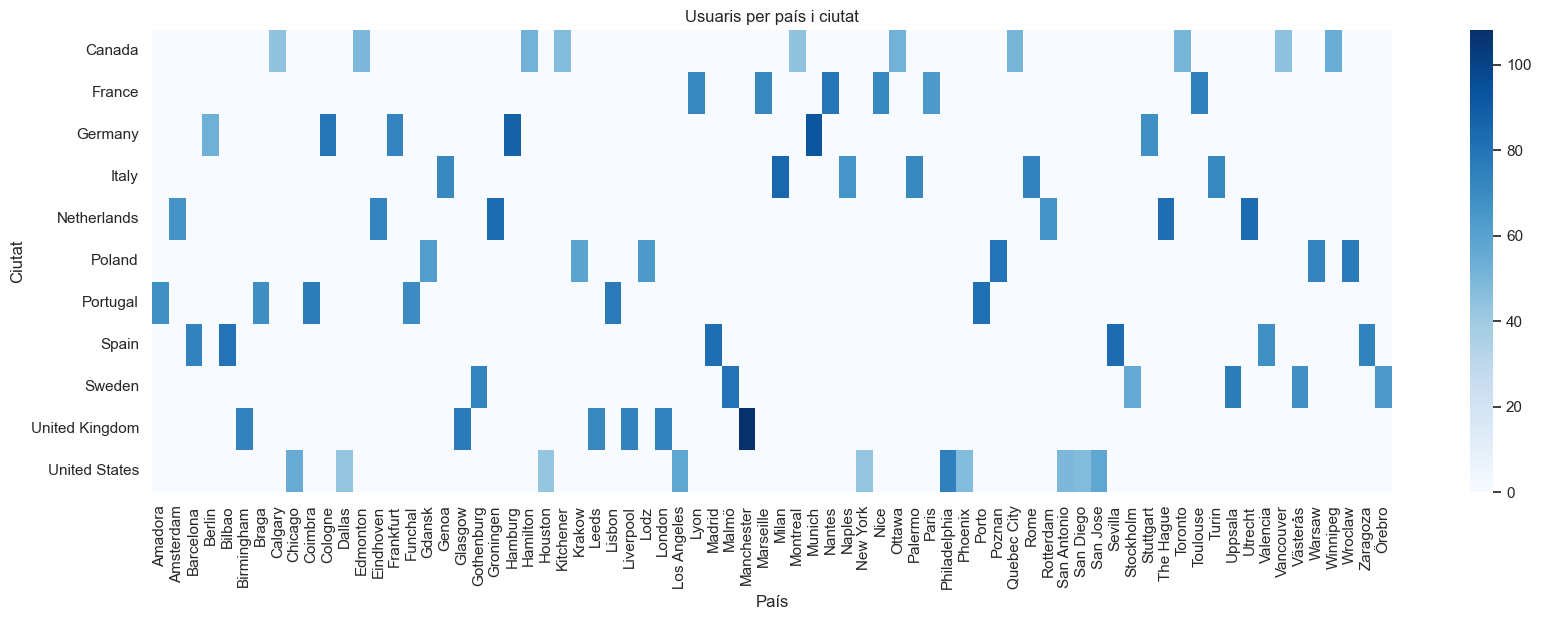

In [229]:
tabla = pd.crosstab(users['country'], users['city'])

plt.figure(figsize=(20,6))
sns.heatmap(tabla, cmap="Blues", cbar=True)
plt.title("Usuaris per país i ciutat")
plt.ylabel("Ciutat")
plt.xlabel("País")
plt.show()

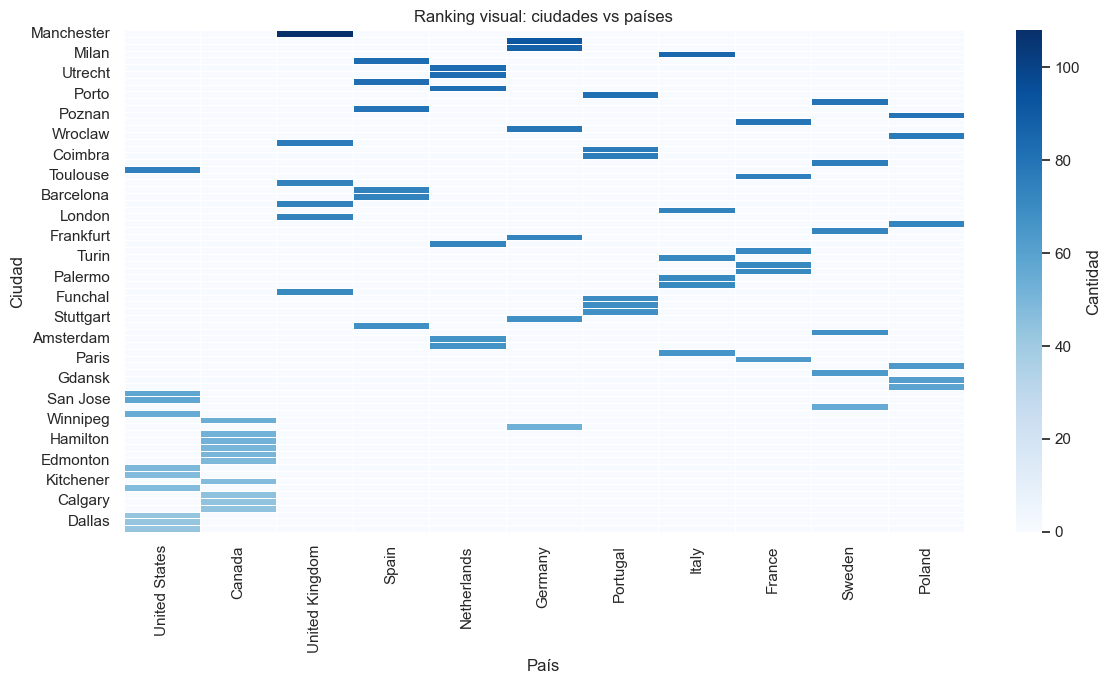

In [231]:
tabla = pd.crosstab(users['city'], users['country'])

# Ranking visual
tabla = tabla.loc[tabla.sum(axis=1).sort_values(ascending=False).index]
tabla = tabla[tabla.sum(axis=0).sort_values(ascending=False).index]

plt.figure(figsize=(12, 7))

sns.heatmap(
    tabla,
    cmap='Blues',
    linewidths=0.5,      # separa celdas
    linecolor='white',   # bordes limpios
    cbar_kws={'label': 'Cantidad'}
)

plt.title('Ranking visual: ciudades vs países')
plt.xlabel('País')
plt.ylabel('Ciudad')

plt.tight_layout()
plt.show()

En el gráfico se muestra el número de personas que pertenecen a cada país y dentro de cada país cuantos usuarios pertenecen a las ciudades pertenecientes a esos países.

- Una variable categòrica i una numèrica

Pandas: barras

Text(0, 0.5, 'Importe medio')

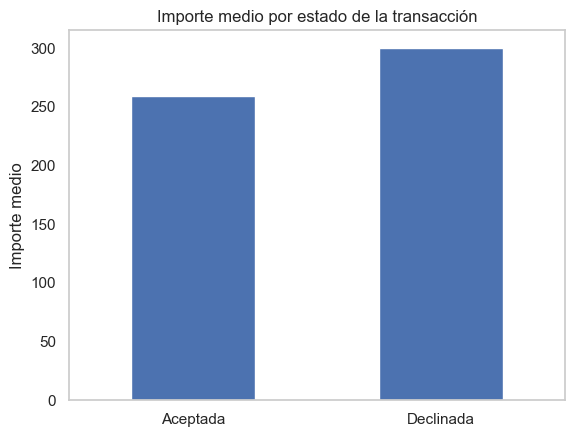

In [274]:
ax = (
    transactions
    .groupby("declined")["amount"]
    .mean()
    .rename(index={0: "Aceptada", 1: "Declinada"})
    .plot.bar(rot=0)
)

ax.set_title("Importe medio por estado de la transacción")
ax.set_xlabel("")
ax.set_ylabel("Importe medio")

Matplotlib: barras

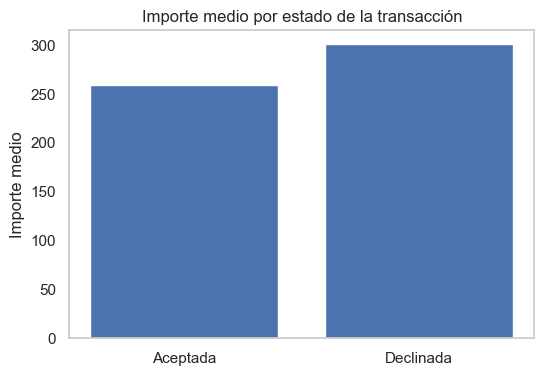

In [275]:
avg_amount = (
    transactions
    .groupby("declined")["amount"]
    .mean()
    .rename(index={0: "Aceptada", 1: "Declinada"})
)

fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(avg_amount.index, avg_amount.values)

ax.set_title("Importe medio por estado de la transacción")
ax.set_xlabel("")
ax.set_ylabel("Importe medio")

plt.show()

Seaborn: barras

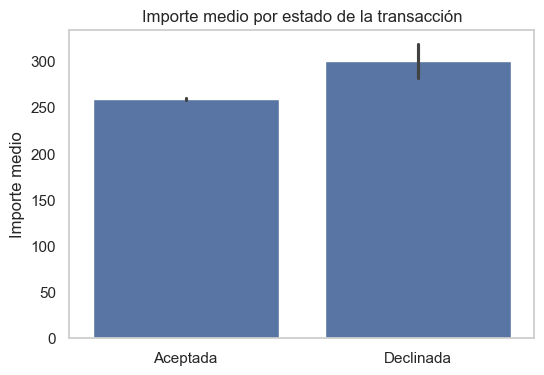

In [297]:
transactions["status"] = transactions["declined"].map({
    0: "Aceptada",
    1: "Declinada"
})

fig, ax = plt.subplots(figsize=(6, 4))

sns.barplot(
    data=transactions,
    x="status",
    y="amount",
    ax=ax
)

ax.set_title("Importe medio por estado de la transacción")
ax.set_xlabel("")
ax.set_ylabel("Importe medio")

plt.show()

In [ ]:
ax.set_title("Importe medio por estado de la transacción")
ax.set_xlabel("")
ax.set_ylabel("Importe medio")

C:\Users\marco\AppData\Local\Temp\ipykernel_27156\755015944.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


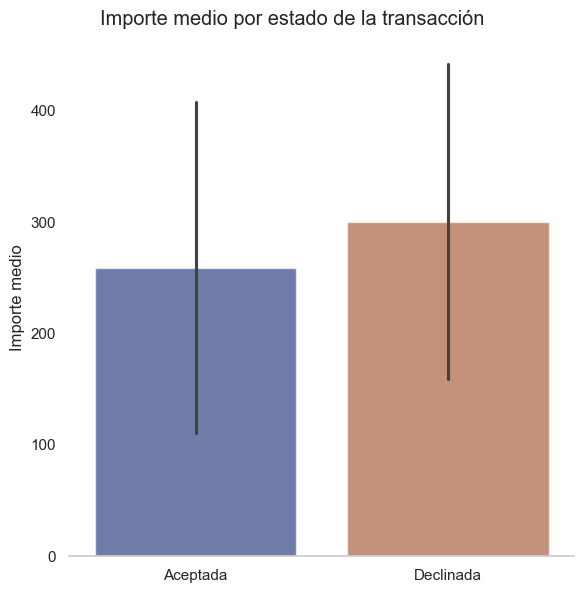

In [300]:
transactions["status"] = transactions["declined"].map({
    0: "Aceptada",
    1: "Declinada"
})

g = sns.catplot(
    data=transactions, kind="bar",
    x="status",
    y="amount",
    errorbar="sd", palette="dark", alpha=.6, height=6
)



g.set_axis_labels("", "Importe medio")
g.figure.suptitle("Importe medio por estado de la transacción", y=1.02)

sns.despine(left=True)

plt.show()

Usando el merge para unir dos tablas

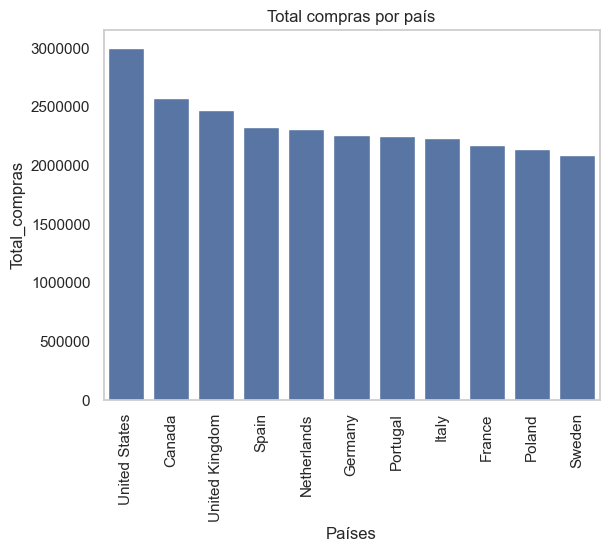

In [303]:
paises_mas_compras = pd.merge(transactions,users, left_on= "user_id", right_on = "id")
paises_mas_compras1=paises_mas_compras[paises_mas_compras['declined']==0].groupby("country")[["amount"]].sum().sort_values(by="amount", ascending=False).reset_index() # si le añades head() te muestra los paises primeros
sns.barplot(data=paises_mas_compras1, x="country", y="amount", errorbar=None)
plt.xlabel("Países")
plt.ylabel("Total_compras")
plt.title("Total compras por país")
plt.xticks(rotation=90)
plt.ticklabel_format(style='plain', axis='y')#para que te muestra los número en formato normal
plt.show()

- Tres variables combinades

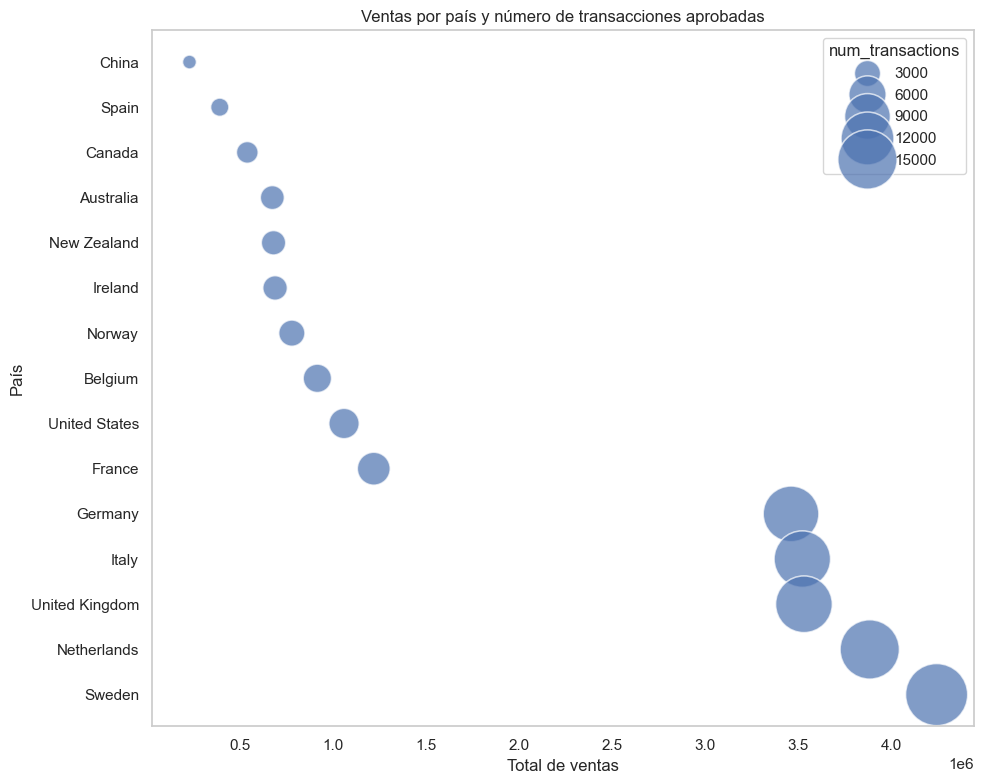

In [ ]:
df_pais = pd.merge(transactions, companies, left_on= "business_id", right_on= "company_id")

df_pais_filtrado = (
    df_pais[df_pais["declined"] == 0]
    .groupby("country")
    .agg(
        total_amount=("amount", "sum"),
        num_transactions=("amount", "count")
    )
    .reset_index()
    .sort_values("total_amount")
)

plt.figure(figsize=(10,8))

sns.scatterplot(
    data=df_pais_filtrado,
    x="total_amount",
    y="country",
    size="num_transactions",
    sizes=(100, 2000),
    alpha=0.7
)

plt.xlabel("Total de ventas")
plt.ylabel("País")
plt.title("Ventas por país y número de transacciones aprobadas")
plt.tight_layout()
plt.show()

En este gráfico se muestra el volumen de ventas por país, siendo el tamaño de la burbuja el número total de transacciones. Como era de esperar, un volumen grande de ventas se corresponde con un mayor número de transacciones. De esta manera, los países con el volumen de ventas más elevado son también los que realizan un mayor número de transacciones, en esta caso, United Kingdown, Sweden y Netherlands.

- Un pairplot

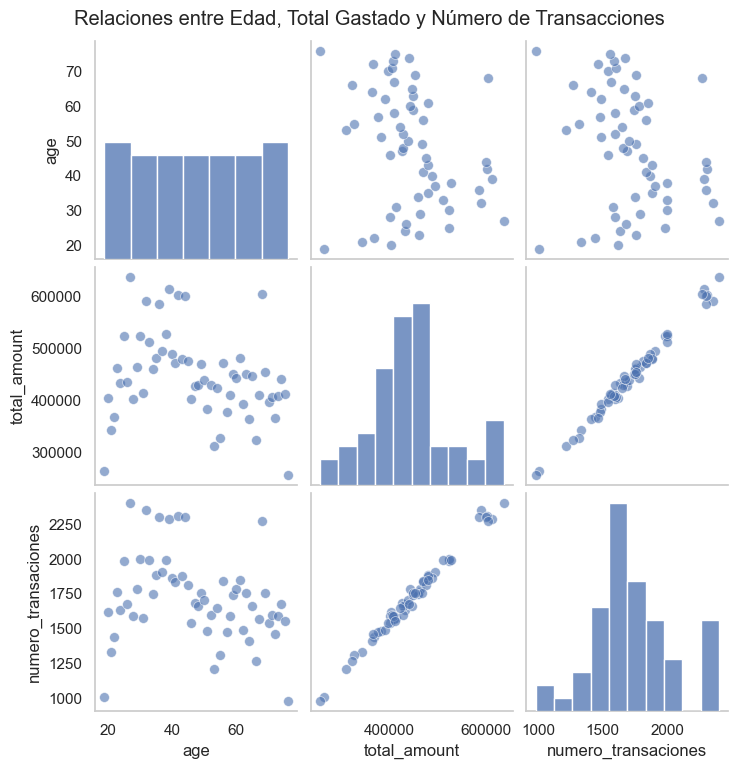

In [288]:
# Calculo la edad

df = pd.merge(
    transactions,
    users,
    left_on="user_id",
    right_on="id"
)

df = df[df["declined"] == 0]

df["birth_date"] = pd.to_datetime(df["birth_date"], errors="coerce")

today = pd.Timestamp.today()

df["age"] = ((today - df["birth_date"]).dt.days // 365)

gasto_por_tran_edad = (
    df.groupby("age").
    agg(total_amount=("amount", "sum"),
        numero_transaciones=("id_x", "count")).
        reset_index().
        sort_values("age")
)

sns.pairplot(
    gasto_por_tran_edad,
    vars=["age","total_amount", "numero_transaciones"],
    kind="scatter",
    diag_kind="hist",  # histograma en la diagonal
    plot_kws={"alpha":0.6, "s":50}  # transparencia y tamaño de puntos
)
plt.suptitle("Relaciones entre Edad, Total Gastado y Número de Transacciones", y=1.02)
plt.show()

En el gráfico se puede observar la distribución de las variables en la diagonal, mientras que en el resto de los gráficos se representan las relaciones entre pares de variables. Analizando el pairplot, se aprecia que la distribución de la edad es bastante uniforme. La relación entre la edad y el número de transacciones no muestra una tendencia clara, por lo que no parece indicar que un mayor número de transacciones esté asociado a una mayor edad. De manera similar, en la relación entre la edad y el total gastado tampoco se observa que un aumento en la edad implique un mayor gasto. Por último, en la relación entre el número de transacciones y el total gastado se aprecia una relación lineal muy fuerte, lo cual era esperable, ya que un mayor número de transacciones suele conllevar un mayor gasto total.

- Fechas

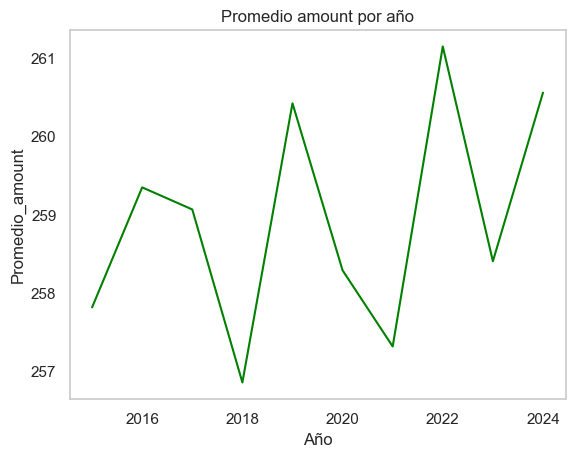

In [282]:
amount_por_año = (
    transactions[transactions["declined"] == 0]
    .groupby(transactions["timestamp"].dt.year)["amount"]
    .mean()
    .reset_index()
)
amount_por_año

sns.lineplot(data= amount_por_año,x="timestamp",y="amount", color="green")
plt.xlabel("Año")
plt.ylabel("Promedio_amount")
plt.title("Promedio amount por año")
plt.show()

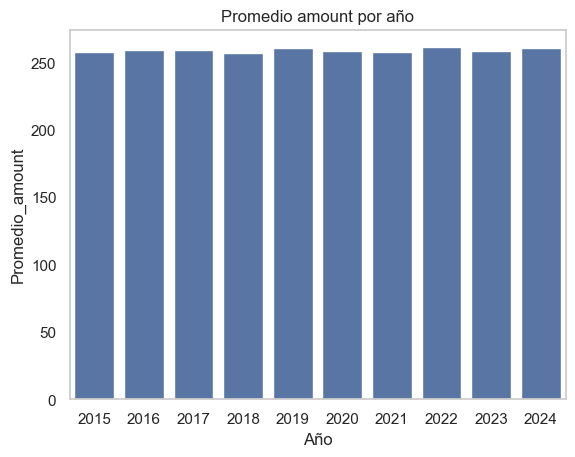

In [283]:
sns.barplot(data= amount_por_año,x="timestamp",y="amount")
plt.xlabel("Año")
plt.ylabel("Promedio_amount")
plt.title("Promedio amount por año")
plt.show()

## NIVELL 2

1. Representa la correlació d'algunes variables i interpreta els resultats segons les teves dades.

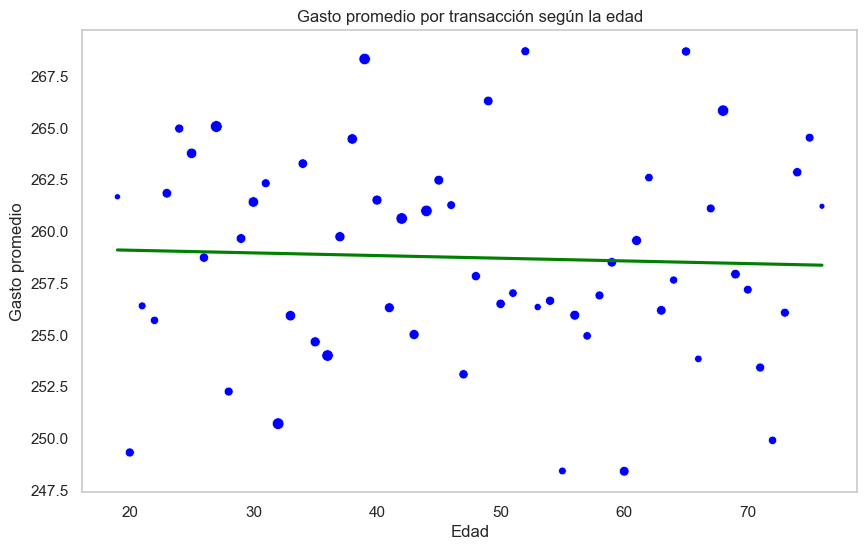

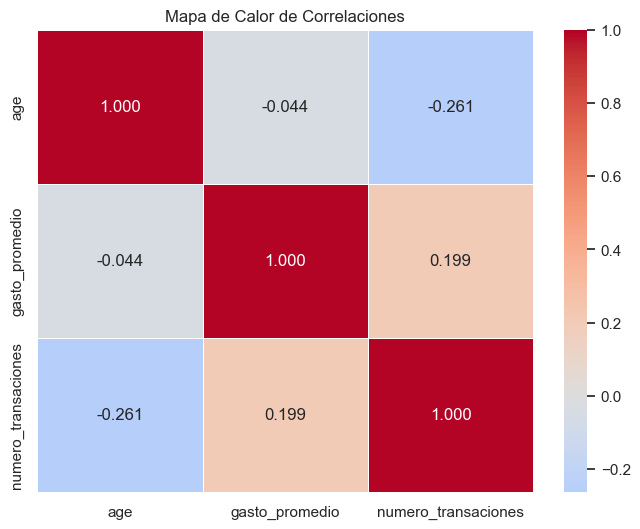

In [316]:
df = pd.merge(
    transactions,
    users,
    left_on="user_id",
    right_on="id"
)

df = df[df["declined"] == 0]

df["birth_date"] = pd.to_datetime(df["birth_date"], errors="coerce")

today = pd.Timestamp.today()

df["age"] = ((today - df["birth_date"]).dt.days // 365)

df5 = (
    df.groupby("age").
    agg(gasto_promedio=("amount", "mean"),
        numero_transaciones=("id_x", "count")).
        reset_index().
        sort_values("age")
)
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="age",
    y="gasto_promedio",
    size="numero_transaciones",
    data=df5,
    legend=False,
    color="blue"
)

sns.regplot(
    x="age",
    y="gasto_promedio",
    data=df5,
    scatter=False,
    color="green",
    ci=None
)

plt.title("Gasto promedio por transacción según la edad")
plt.xlabel("Edad")
plt.ylabel("Gasto promedio")
plt.show()


df5.corr()

# 1. Calcular la matriz de correlación
corr_matrix = df5.corr()

# 2. Configurar el gráfico
plt.figure(figsize=(8, 6))

# 3. Crear el heatmap
sns.heatmap(
    corr_matrix, 
    annot=True,      # Muestra los números dentro de los cuadros
    cmap='coolwarm', # Escala de colores (azul para negativo, rojo para positivo)
    fmt=".3f",       # Formato de 3 decimales
    center=0,        # El color blanco será el 0
    linewidths=0.5   # Espacio entre cuadros
)

plt.title('Mapa de Calor de Correlaciones')
plt.show()

Al observar los colores y valores del gráfico generado:
• Correlación Edad vs. Gasto Promedio (0.034). Como el color es muy pálido (cercano al blanco/neutro), se confirma visualmente que no hay relación entre la edad y cuánto gasta un usuario en promedio. La edad no influye en el ticket medio.
• Correlación Edad vs. Número de Transacciones (-0.372): Este es el valor más significativo. Al ser un tono azulado (negativo), nos indica que a mayor edad, menor es el número de transacciones. Es una correlación negativa moderada.
• Gasto Promedio vs. Número de Transacciones (-0.148): Existe una relación negativa muy débil. Esto podría sugerir que los usuarios que hacen muchísimas compras tienden a gastar un poco menos en cada una (compras pequeñas pero frecuentes), pero la relación no es lo suficientemente fuerte como para ser una regla clara.

2. Implementa un Jointplot per explorar la relació entre dues variables i interpreta els resultats segons les teves dades.

el coeficiente de correlació és -0.26


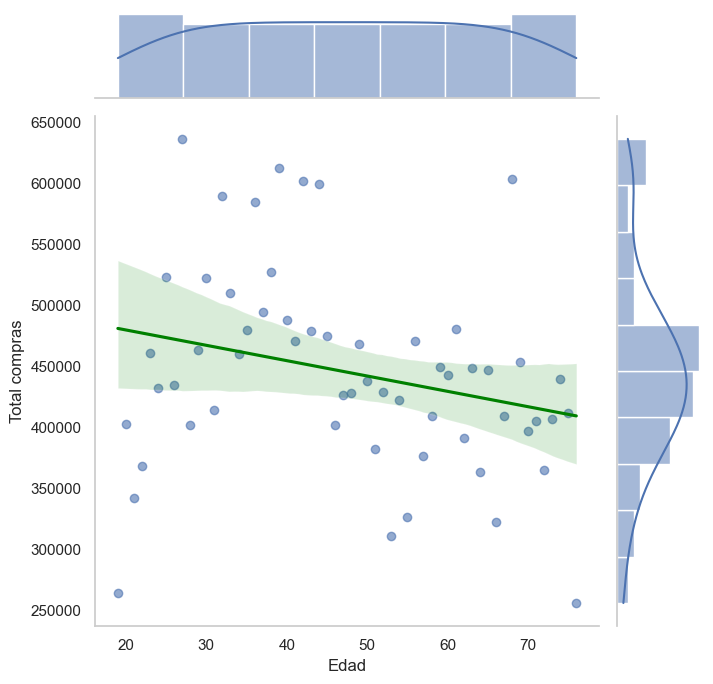

In [317]:

g = sns.jointplot(x = "age", y = "total_amount", data = gasto_por_tran_edad,   
    kind="reg",      # scatter + línea de regresión
    height=7,
    scatter_kws={"alpha": 0.6},
    line_kws={"color": "green"})

g.set_axis_labels("Edad", "Total compras")

x = gasto_por_tran_edad["age"]
y = gasto_por_tran_edad["total_amount"]

r = np.corrcoef(x, y)[0, 1].round(2)
print(f"el coeficiente de correlació és {r}")
# gasto_por_tran_edad

## NIVELL 3

1. Transfereix totes les visualitzacions del Nivell 1 a Power BI utilitzant scripts de Python.

Recorda: quan carreguis els teus dataframes a Power BI, assegura't d’incloure una columna identificadora o una combinació de columnes que garanteixi la unicitat de cada registre. Per defecte, Power BI elimina duplicats i podries perdre informació.